# Sigma_epsilon (Observation Noise) Sensitivity Test

Testing how observation noise σ_ε² affects rho learning in the SG-ICM model.

**Key parameters:**
- Test observation_noise values: [0.0001, 0.001, 0.01, 0.1]
- Fixed sigma_zeta = 1e-2 (best from previous test)
- 1000 environments × 15 steps
- True correlations: ρ = [+0.6, 0.0, -0.6] for 3 peers

**Hypothesis**: Larger σ_ε² keeps GP uncertainty higher → sustained learning rates → less oscillation

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

from model import SocialGPModel
from rewards import (
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    _min_max,
)

In [3]:
# Display settings
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

## Setup: Define Test Conditions

In [4]:
# Correlation matrix and true rho values
corr_matrix = build_corr_matrix_option1()
rho_true = corr_matrix[0]  # [1.0, 0.6, 0.0, -0.6]
rho_zero = np.array([1.0, 0.0, 0.0, 0.0])
n_children = corr_matrix.shape[0] - 1
grid_size = 11

print(f"True correlation matrix:")
print(corr_matrix)
print(f"\nTrue rho for main agent: {rho_true}")
print(f"Peer correlations: {rho_true[1:]}")

True correlation matrix:
[[ 1.   0.6  0.  -0.6]
 [ 0.6  1.   0.   0. ]
 [ 0.   0.   1.   0. ]
 [-0.6  0.   0.   1. ]]

True rho for main agent: [ 1.   0.6  0.  -0.6]
Peer correlations: [ 0.6  0.  -0.6]


In [5]:
# Define sigma_epsilon (observation_noise) test conditions
sigma_eps_conditions = {
    "eps_0.0001": {
        "label": "σ_ε²=0.0001",
        "observation_noise": 0.0001,
    },
    "eps_0.001": {
        "label": "σ_ε²=0.001",
        "observation_noise": 0.001,
    },
    "eps_0.01": {
        "label": "σ_ε²=0.01",
        "observation_noise": 0.01,
    },
    "eps_0.1": {
        "label": "σ_ε²=0.1",
        "observation_noise": 0.1,
    },
}

# Add baseline conditions for comparison
baseline_conditions = {
    "baseline_calibrated": {
        "label": "SG-ICM calibrated",
        "observation_noise": 0.0001,
        "rho": rho_true,
        "rho_update_rule": None,
    },
    "baseline_asocial": {
        "label": "AS",
        "observation_noise": 0.0001,
        "rho": rho_zero,
        "rho_update_rule": None,
    },
}

all_conditions = {**sigma_eps_conditions, **baseline_conditions}
print(f"Testing {len(all_conditions)} conditions:")
for name, cfg in all_conditions.items():
    print(f"  - {cfg['label']}")

Testing 6 conditions:
  - σ_ε²=0.0001
  - σ_ε²=0.001
  - σ_ε²=0.01
  - σ_ε²=0.1
  - SG-ICM calibrated
  - AS


In [6]:
n_envs = 1000
n_steps = 15

def generate_env(env_seed, grid_size=11):
    """Generate a reward environment with specified seed"""
    rng = np.random.default_rng(env_seed)
    parent, child_maps = make_parent_and_children_cholesky2(
        rng=rng,
        grid_size=grid_size,
        n_children=n_children + 1,
        length_scale=2.0,
        corr_matrix=corr_matrix,
    )
    child_maps = [_min_max(c) - 0.5 for c in child_maps]
    return parent, child_maps


def get_agent0_rho(model):
    """Extract rho vector from the main agent (Agent 0)"""
    agent = model.grid.agents[0]
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    if agent._rho_updater is None:
        return np.array(agent.rho, dtype=float)
    return agent._rho_updater.get_rho_vector(neighbors)


def run_sigma_eps_condition(condition_name, condition_cfg, parent, child_maps, n_steps=15, seed=0):
    """Run a single condition with specific observation_noise value"""
    
    observation_noise = condition_cfg["observation_noise"]
    rho = condition_cfg.get("rho", rho_zero)
    rho_update_rule = condition_cfg.get("rho_update_rule", "rho_kalman")
    
    m = SocialGPModel(
        n=n_children + 1,
        child_maps=[parent] + child_maps,
        network_type="directed_one_to_four",
        model_type="SG-ICM",
        rho=rho,
        rho_update_rule=rho_update_rule,
        rho_update_init=0.0,
        rho_update_sigma_zeta=1e-1,  # Fixed at best value from sigma_zeta test
        rho_update_basis="full",
        observation_noise_private=observation_noise,  # TEST THIS
        tau=0.03,
        beta_private=0.33,
        length_scale_private=1.11,
        length_scale_social=1.11,
        length_scale_is_identical=True,
        seed=seed,
    )

    rho_history = []
    for _ in range(n_steps):
        m.step()
        rho_history.append(get_agent0_rho(m))

    df = m.datacollector.get_agent_vars_dataframe().reset_index()
    df["condition"] = condition_name
    df["condition_label"] = condition_cfg["label"]
    df["observation_noise"] = observation_noise
    df["seed"] = seed
    return df, np.array(rho_history)

In [7]:
# Run experiment
results_list = []
rho_histories = []

for env_seed in tqdm(range(n_envs), desc="Testing sigma_epsilon"):
    parent, child_maps = generate_env(env_seed, grid_size=grid_size)
    
    for condition_name, condition_cfg in all_conditions.items():
        df, rho_hist = run_sigma_eps_condition(
            condition_name,
            condition_cfg,
            parent,
            child_maps,
            n_steps=n_steps,
            seed=env_seed,
        )
        results_list.append(df)
        rho_histories.append({
            "condition": condition_name,
            "condition_label": condition_cfg["label"],
            "observation_noise": condition_cfg["observation_noise"],
            "seed": env_seed,
            "rho_history": rho_hist,
        })

results_df = pd.concat(results_list, ignore_index=True)
results_df.head()

Testing sigma_epsilon: 100%|██████████| 1000/1000 [03:07<00:00,  5.35it/s]



Experiment complete! Total rows: 360,000


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,condition,condition_label,observation_noise,seed
0,1,1,"(9, 9)",-0.122874,-0.122874,SG-ICM,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,eps_0.0001,σ_ε²=0.0001,0.0001,0
1,1,2,"(5, 4)",-0.123619,-0.123619,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,eps_0.0001,σ_ε²=0.0001,0.0001,0
2,1,3,"(9, 8)",-0.050029,-0.050029,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,eps_0.0001,σ_ε²=0.0001,0.0001,0
3,1,4,"(3, 10)",-0.303291,-0.303291,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,eps_0.0001,σ_ε²=0.0001,0.0001,0
4,2,1,"(0, 8)",1.192735,1.069861,SG-ICM,0.03,4.637447,9.055385,9.055385,9.055385,6.336225,6.336225,3.605551,eps_0.0001,σ_ε²=0.0001,0.0001,0


## Visualization: Rho Learning Trajectories

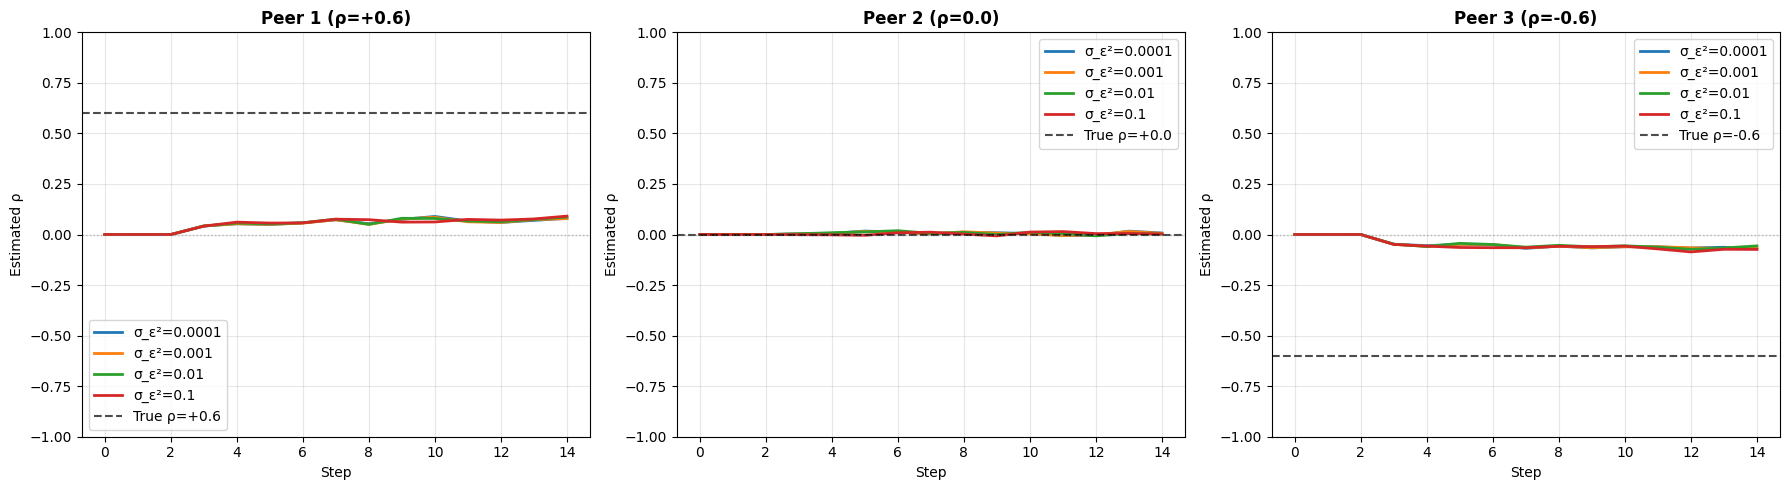

In [ ]:
def plot_rho_trajectories_3peers(rho_hist_list, true_rho_values, exclude_baselines=True):
    """Plot estimated rho over time for each of the 3 peers"""
    
    # Group by condition
    condition_data = {}
    for entry in rho_hist_list:
        cond = entry["condition"]
        label = entry["condition_label"]
        
        if exclude_baselines and ("baseline" in cond):
            continue
            
        if cond not in condition_data:
            condition_data[cond] = {"label": label, "histories": []}
        condition_data[cond]["histories"].append(entry["rho_history"])
    
    # Compute mean trajectory for each condition
    mean_trajectories = {}
    for cond, data in condition_data.items():
        histories = np.stack(data["histories"], axis=0)
        mean_traj = np.mean(histories, axis=0)
        mean_trajectories[cond] = {"label": data["label"], "traj": mean_traj}
    
    # Plot 3 subplots (one per peer)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    peer_names = ["Peer 1 (ρ=+0.6)", "Peer 2 (ρ=0.0)", "Peer 3 (ρ=-0.6)"]
    
    for peer_idx, (ax, peer_name, true_val) in enumerate(zip(axes, peer_names, true_rho_values)):
        for cond, data in mean_trajectories.items():
            rho_over_time = data["traj"][:, peer_idx + 1]
            ax.plot(rho_over_time, label=data["label"], linewidth=2)
        
        ax.axhline(true_val, linestyle='--', color='black', alpha=0.7, linewidth=1.5, 
                   label=f'True ρ={true_val:+.1f}')
        ax.axhline(0, linestyle=':', color='gray', alpha=0.5, linewidth=1)
        
        ax.set_title(peer_name, fontsize=12, fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("Estimated ρ")
        ax.set_ylim(-1.0, 1.0)
        ax.grid(alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    # plt.savefig("../sigma_eps_rho_trajectories.png", dpi=150, bbox_inches='tight')
    plt.show()

# Plot
true_rho_peers = rho_true[1:]  # Extract [0.6, 0.0, -0.6]
plot_rho_trajectories_3peers(rho_histories, true_rho_peers, exclude_baselines=True)

## Visualization: MAE Convergence

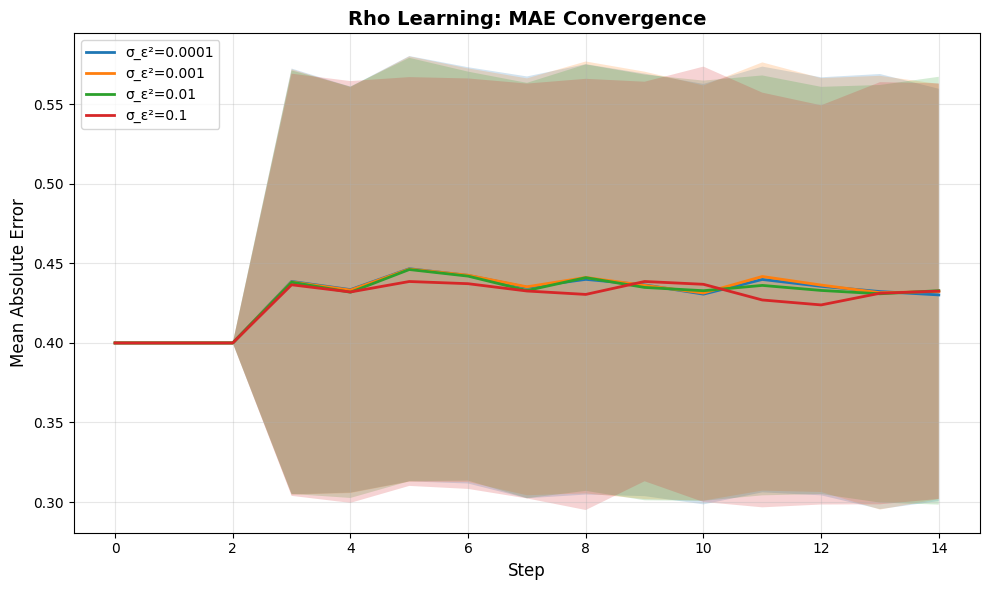

In [ ]:
def plot_mae_convergence(rho_hist_list, true_rho_values, exclude_baselines=True):
    """Plot mean absolute error of rho estimates over time"""
    
    condition_data = {}
    for entry in rho_hist_list:
        cond = entry["condition"]
        label = entry["condition_label"]
        
        if exclude_baselines and ("baseline" in cond):
            continue
            
        if cond not in condition_data:
            condition_data[cond] = {"label": label, "histories": []}
        condition_data[cond]["histories"].append(entry["rho_history"])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for cond, data in condition_data.items():
        histories = np.stack(data["histories"], axis=0)
        estimates = histories[:, :, 1:]
        mae = np.abs(estimates - true_rho_values).mean(axis=2)
        mean_mae = mae.mean(axis=0)
        std_mae = mae.std(axis=0)
        
        steps = np.arange(len(mean_mae))
        ax.plot(steps, mean_mae, label=data["label"], linewidth=2)
        ax.fill_between(steps, mean_mae - std_mae, mean_mae + std_mae, alpha=0.2)
    
    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel("Mean Absolute Error", fontsize=12)
    ax.set_title("Rho Learning: MAE Convergence", fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    # plt.savefig("../sigma_eps_mae_convergence.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_mae_convergence(rho_histories, true_rho_peers, exclude_baselines=True)

## Visualization: Final Performance Comparison

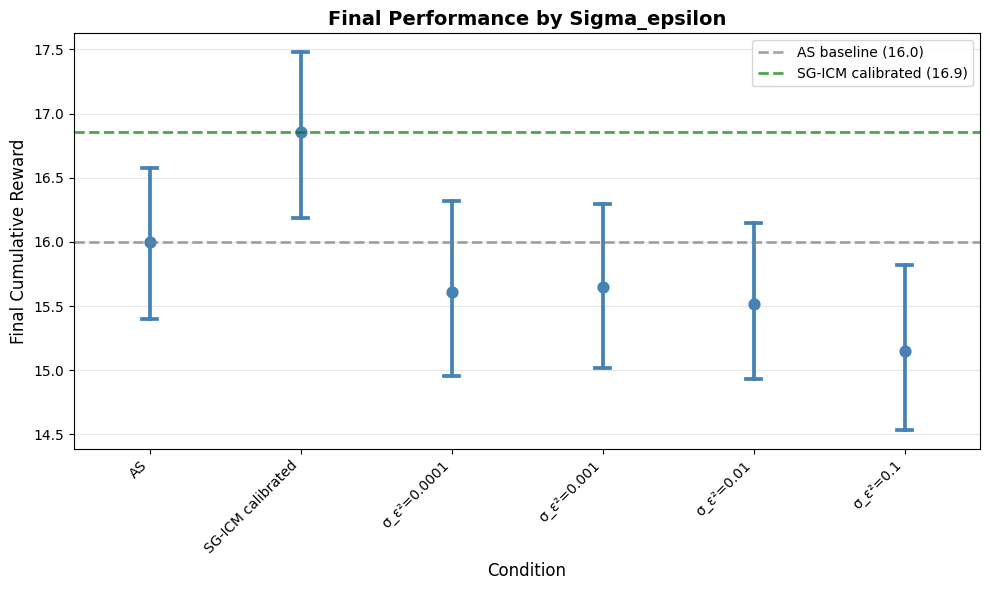

In [ ]:
def _select_sg_agent(df):
    """Select only the SG-ICM agent (or first agent) from dataframe"""
    plot_df = df.copy()
    if "model_type" in plot_df.columns:
        sg = plot_df[(plot_df["model_type"] == "SG-ICM") | (plot_df["model_type"] == "SG")].copy()
        if not sg.empty:
            return sg
    if "AgentID" in plot_df.columns:
        min_id = plot_df["AgentID"].min()
        return plot_df[plot_df["AgentID"] == min_id].copy()
    return plot_df


def plot_final_performance_sigma_eps(df):
    """Compare final cumulative rewards across sigma_epsilon values"""
    
    plot_df = _select_sg_agent(df)
    
    final_step = plot_df.groupby(["seed", "condition_label"])["Step"].transform('max')
    final_df = plot_df[plot_df['Step'] == final_step].copy()
    
    label_order = sorted(final_df["condition_label"].unique())
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.pointplot(
        data=final_df,
        x="condition_label",
        y="cumulative_reward",
        order=label_order,
        errorbar=('ci', 95),
        linestyle='none',
        markers='o',
        ax=ax,
        capsize=0.1,
        color='steelblue',
    )
    
    # Add baseline reference lines
    as_mean = final_df.loc[final_df["condition_label"] == "AS", "cumulative_reward"].mean()
    calib_mean = final_df.loc[final_df["condition_label"] == "SG-ICM calibrated", "cumulative_reward"].mean()
    
    if pd.notna(as_mean):
        ax.axhline(as_mean, linestyle='--', color='gray', alpha=0.7, linewidth=2, 
                   label=f'AS baseline ({as_mean:.1f})')
    if pd.notna(calib_mean):
        ax.axhline(calib_mean, linestyle='--', color='green', alpha=0.7, linewidth=2, 
                   label=f'SG-ICM calibrated ({calib_mean:.1f})')
    
    ax.set_xlabel("Condition", fontsize=12)
    ax.set_ylabel("Final Cumulative Reward", fontsize=12)
    ax.set_title("Final Performance by Sigma_epsilon", fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=10)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    # plt.savefig("../sigma_eps_final_performance.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_final_performance_sigma_eps(results_df)

## Summary Statistics

In [ ]:
def compute_summary_stats(rho_hist_list, results_df, true_rho_values):
    """Compute final MAE and performance for each condition"""
    
    summary = []
    
    condition_data = {}
    for entry in rho_hist_list:
        cond = entry["condition"]
        label = entry["condition_label"]
        
        if cond not in condition_data:
            condition_data[cond] = {"label": label, "histories": [], "observation_noise": entry["observation_noise"]}
        condition_data[cond]["histories"].append(entry["rho_history"])
    
    for cond, data in condition_data.items():
        # Final MAE
        histories = np.stack(data["histories"], axis=0)
        final_estimates = histories[:, -1, 1:]
        final_mae = np.abs(final_estimates - true_rho_values).mean()
        
        # Per-peer final MAE
        peer1_mae = np.abs(final_estimates[:, 0] - true_rho_values[0]).mean()
        peer2_mae = np.abs(final_estimates[:, 1] - true_rho_values[1]).mean()
        peer3_mae = np.abs(final_estimates[:, 2] - true_rho_values[2]).mean()
        
        # Final performance
        sg_agent_df = _select_sg_agent(results_df[results_df["condition"] == cond])
        final_step = sg_agent_df.groupby("seed")["Step"].transform('max')
        final_rewards = sg_agent_df[sg_agent_df["Step"] == final_step]["cumulative_reward"]
        mean_reward = final_rewards.mean()
        std_reward = final_rewards.std()
        
        summary.append({
            "condition": cond,
            "label": data["label"],
            "observation_noise": data["observation_noise"],
            "final_mae": final_mae,
            "peer1_mae (ρ=+0.6)": peer1_mae,
            "peer2_mae (ρ=0.0)": peer2_mae,
            "peer3_mae (ρ=-0.6)": peer3_mae,
            "mean_reward": mean_reward,
            "std_reward": std_reward,
        })
    
    return pd.DataFrame(summary).sort_values("observation_noise")

summary_stats = compute_summary_stats(rho_histories, results_df, true_rho_peers)
print(summary_stats.to_string(index=False))


SIGMA_EPSILON SENSITIVITY ANALYSIS - SUMMARY
          condition             label  observation_noise  final_mae  peer1_mae (ρ=+0.6)  peer2_mae (ρ=0.0)  peer3_mae (ρ=-0.6)  mean_reward  std_reward
         eps_0.0001       σ_ε²=0.0001             0.0001   0.430196            0.547592           0.190188            0.552809    15.611993   10.528660
baseline_calibrated SG-ICM calibrated             0.0001   0.000000            0.000000           0.000000            0.000000    16.855245   10.034043
   baseline_asocial                AS             0.0001   0.400000            0.600000           0.000000            0.600000    15.996953    9.769698
          eps_0.001        σ_ε²=0.001             0.0010   0.432329            0.549047           0.191173            0.556765    15.650682   10.484523
           eps_0.01         σ_ε²=0.01             0.0100   0.432857            0.541051           0.188931            0.568589    15.515036   10.348554
            eps_0.1          σ_ε²=0.1     

## Oscillation Analysis

Check if larger observation_noise reduces oscillations.

In [12]:
# Compute oscillation metrics for each sigma_epsilon value
print("\n" + "="*80)
print("OSCILLATION METRICS BY SIGMA_EPSILON")
print("="*80)

condition_data = {}
for entry in rho_histories:
    cond = entry["condition"]
    label = entry["condition_label"]
    
    if "baseline" in cond:
        continue
        
    if cond not in condition_data:
        condition_data[cond] = {"label": label, "histories": []}
    condition_data[cond]["histories"].append(entry["rho_history"])

for cond, data in sorted(condition_data.items()):
    histories = np.stack(data["histories"], axis=0)  # (n_envs, n_steps, 4)
    
    print(f"\n{data['label']}:")
    print("-" * 40)
    
    # Average across all 3 peers
    all_peers = histories[:, :, 1:]  # (n_envs, n_steps, 3)
    
    # Range (max - min) for each trajectory
    ranges = all_peers.reshape(len(histories), -1, 3).max(axis=1) - all_peers.reshape(len(histories), -1, 3).min(axis=1)
    avg_range = ranges.mean()
    
    # Average absolute change per step
    diffs = np.abs(np.diff(all_peers, axis=1))  # (n_envs, n_steps-1, 3)
    avg_abs_change = diffs.mean()
    
    print(f"  Avg range (max-min): {avg_range:.3f}")
    print(f"  Avg |Δρ| per step:   {avg_abs_change:.4f}")
    
    if avg_range > 1.5:
        print(f"  ⚠️  HIGH OSCILLATION")
    elif avg_range > 1.0:
        print(f"  ⚠️  MODERATE OSCILLATION")
    else:
        print(f"  ✓  LOW OSCILLATION")

print("\n" + "="*80)
print("\nKEY QUESTION: Does larger sigma_epsilon reduce oscillation?")
print("  - If range decreases with larger σ_ε²: YES, hypothesis confirmed")
print("  - If range stays similar: NO, oscillation is not due to GP overconfidence")


OSCILLATION METRICS BY SIGMA_EPSILON

σ_ε²=0.0001:
----------------------------------------
  Avg range (max-min): 0.952
  Avg |Δρ| per step:   0.2153
  ✓  LOW OSCILLATION

σ_ε²=0.001:
----------------------------------------
  Avg range (max-min): 0.953
  Avg |Δρ| per step:   0.2159
  ✓  LOW OSCILLATION

σ_ε²=0.01:
----------------------------------------
  Avg range (max-min): 0.951
  Avg |Δρ| per step:   0.2156
  ✓  LOW OSCILLATION

σ_ε²=0.1:
----------------------------------------
  Avg range (max-min): 0.953
  Avg |Δρ| per step:   0.2207
  ✓  LOW OSCILLATION


KEY QUESTION: Does larger sigma_epsilon reduce oscillation?
  - If range decreases with larger σ_ε²: YES, hypothesis confirmed
  - If range stays similar: NO, oscillation is not due to GP overconfidence
